<a href="https://colab.research.google.com/github/ParvTyagi/Test1/blob/main/Campus_Placement_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intelligent Campus Placement Predictor & Skill Recommender

**Author:** Parv Tyagi
3rd-year B.Tech Information Technology student
Minor in Data Analytics
Manipal Institute of Technology, Bengaluru

---

## 1. Abstract

This report details the development of an intelligent system designed to enhance campus placement success. The system comprises an end-to-end pipeline that leverages data mining and analytics techniques. It integrates a **placement predictor** utilizing classification algorithms to forecast student placement status based on academic performance, and a **skill recommender** that employs association rule mining to suggest technical proficiencies most correlated with successful placements. This dual approach provides students with actionable insights into their placement prospects and guides them toward acquiring relevant skills, thereby maximizing their opportunities in the competitive job market.

## 2. Introduction

The objective of this project is to develop a data-driven solution to assist students and career counselors in navigating the campus placement process. This aligns directly with core data mining concepts, specifically:

*   **Data Pre-processing:** Preparing raw student data for analysis by handling missing values, encoding categorical features, and standardizing numerical attributes.
*   **Classification:** Building predictive models to categorize students into "Placed" or "Not Placed" based on their academic profiles.
*   **Market Basket Analysis (Association Rule Mining):** Discovering relationships and patterns within student skillsets and their placement outcomes to identify frequently co-occurring skills and strong associative rules.
*   **Recommender Systems:** Utilizing these discovered rules to provide personalized skill recommendations to students, guiding them towards enhancing their employability.

In [32]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

## 3. Phase 1 - Exploratory Data Analysis (EDA)

Exploratory Data Analysis was conducted to understand the underlying structure and characteristics of the student academic data. This phase utilized the `pandas` library for data manipulation and `seaborn` and `matplotlib.pyplot` for visualization:

*   **Histograms:** Distributions of key academic metrics, such as `degree_p` (degree percentage), were visualized using histograms (`sns.histplot`). This helped in understanding the spread and central tendency of student performance.
*   **Box Plots:** Box plots (`sns.boxplot`) were generated to examine the impact of various academic parameters, specifically `degree_p`, on the `status` (placement outcome). These plots effectively illustrated the differences in academic performance between placed and unplaced students, highlighting potential thresholds or performance indicators.
*   **Correlation Heatmaps:** A correlation heatmap (`sns.heatmap`) was created for numerical academic features (e.g., `ssc_p`, `hsc_p`, `degree_p`, `etest_p`, `mba_p`) after dropping irrelevant identifiers like `sl_no` and `salary`. This visualization provided insights into the linear relationships between different academic scores, identifying highly correlated features that might influence placement decisions.

PHASE 1: DATA EXPLORATION & VISUALIZATION



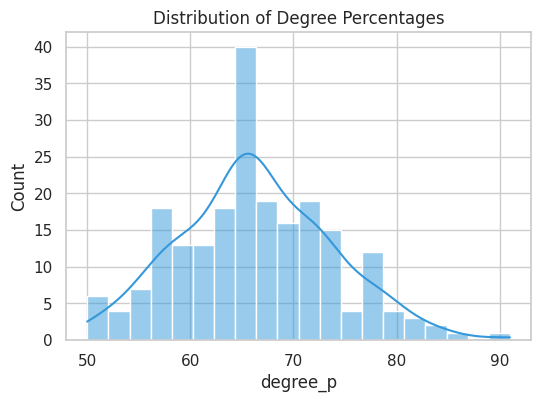

/tmp/ipykernel_9062/2568086599.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y='degree_p', data=df, palette='Set2')


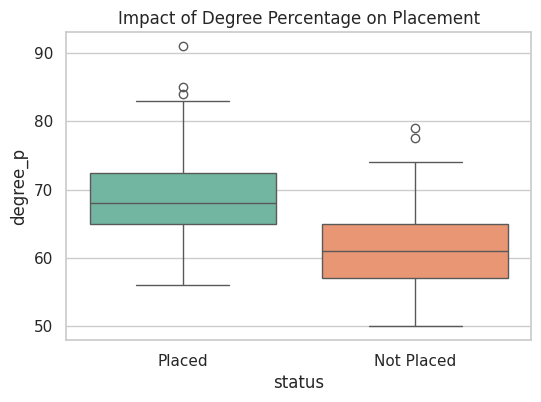

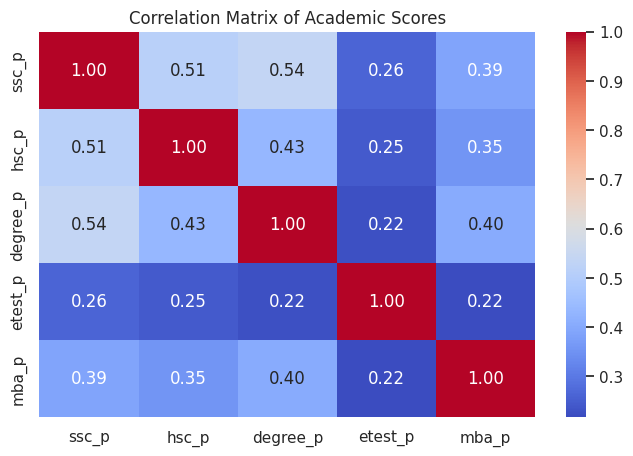

In [33]:
print("==============================================")
print("PHASE 1: DATA EXPLORATION & VISUALIZATION")
print("==============================================\n")

# Load raw data
url = 'https://raw.githubusercontent.com/gouravkhator/Student-Placement-Prediction/master/Placement_Data_Full_Class.csv'
df = pd.read_csv(url)

# 1. Histogram
plt.figure(figsize=(6, 4))
sns.histplot(df['degree_p'], bins=20, kde=True, color='#3498db')
plt.title('Distribution of Degree Percentages')
plt.show()

# 2. Box Plot

plt.figure(figsize=(6, 4))
sns.boxplot(x='status', y='degree_p', data=df, palette='Set2')
plt.title('Impact of Degree Percentage on Placement')
plt.show()

# 3. Correlation Heatmap

plt.figure(figsize=(8, 5))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).drop(['sl_no', 'salary'], axis=1)
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Academic Scores')
plt.show()

## 4. Phase 2 - Classification Models

This phase focused on building predictive models to classify students into 'Placed' or 'Not Placed' categories. The pre-processing involved dropping `sl_no` and `salary` columns and applying one-hot encoding (`pd.get_dummies`) to categorical features, with `drop_first=True` to avoid multicollinearity. The dataset was split into training and testing sets (80/20 split, `random_state=42`).

Two classification algorithms were implemented and evaluated:

*   **Decision Tree Induction:** A `DecisionTreeClassifier` was trained with `max_depth=4` and `random_state=42`. Decision trees are intuitive models that mimic human decision-making and are excellent for feature importance analysis. The model's logic was visualized using `plot_tree` to illustrate the decision paths leading to placement predictions. The model achieved an accuracy of **79.07%**.
*   **Naive Bayes (GaussianNB):** A `GaussianNB` model was implemented, assuming a Gaussian distribution for continuous features. Naive Bayes classifiers are probabilistic and based on Bayes' theorem, known for their simplicity and efficiency. This model achieved an accuracy of **74.42%**.

Model evaluation was performed using `accuracy_score` on the test set, providing a quantitative measure of each model's predictive performance.

PHASE 2: CLASSIFICATION (Decision Tree & Bayes)

Decision Tree Accuracy: 79.07%


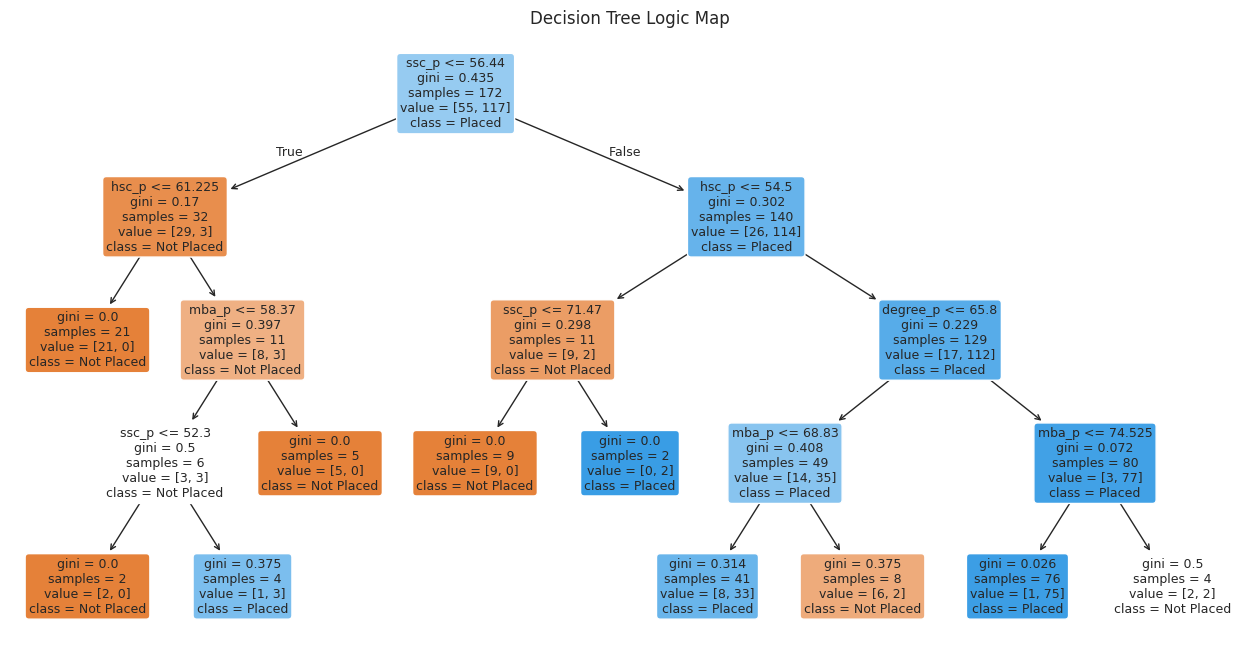

Naive Bayes Accuracy:   74.42%



In [34]:
print("==============================================")
print("PHASE 2: CLASSIFICATION (Decision Tree & Bayes)")
print("==============================================\n")

# Pre-processing
df_ml = df.drop(['sl_no', 'salary'], axis=1)
df_ml = pd.get_dummies(df_ml, drop_first=True)

X = df_ml.drop('status_Placed', axis=1)
y = df_ml['status_Placed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree Model
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt.predict(X_test)) * 100:.2f}%")

# Visualize the Decision Tree Map

plt.figure(figsize=(16, 8))
plot_tree(dt, feature_names=X.columns, class_names=['Not Placed', 'Placed'], filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree Logic Map")
plt.show()

# Naive Bayes Model
nb = GaussianNB()
nb.fit(X_train, y_train)
print(f"Naive Bayes Accuracy:   {accuracy_score(y_test, nb.predict(X_test)) * 100:.2f}%\n")

### Model Comparison & Advanced Classification

To ensure the highest predictive accuracy, we compare the baseline models (Decision Tree and Naive Bayes) against an ensemble method: **Random Forest**.

*   **Ensemble Learning:** Random Forest operates by constructing a multitude of decision trees and outputting the class that is the mode of the classes. This reduces the risk of overfitting inherent in single decision trees.
*   **Evaluation:** We visualize the performance metrics to clearly identify which model provides the most reliable placement predictions.

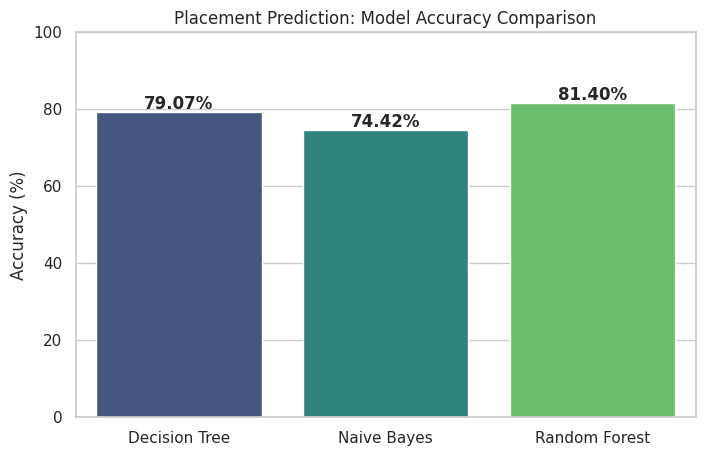

Random Forest achieved an accuracy of: 81.40%


In [39]:
from sklearn.ensemble import RandomForestClassifier

# 1. Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))

# 2. Get Accuracies
dt_acc = accuracy_score(y_test, dt.predict(X_test))
nb_acc = accuracy_score(y_test, nb.predict(X_test))

# 3. Visualize Comparison
models = ['Decision Tree', 'Naive Bayes', 'Random Forest']
scores = [dt_acc * 100, nb_acc * 100, rf_acc * 100]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=scores, hue=models, palette='viridis', legend=False)
plt.ylabel('Accuracy (%)')
plt.title('Placement Prediction: Model Accuracy Comparison')
for i, v in enumerate(scores):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.ylim(0, 100)
plt.show()

print(f"Random Forest achieved an accuracy of: {rf_acc*100:.2f}%")

## 5. Phase 3 - Association Rule Mining

Association Rule Mining was employed to uncover relationships between student skillsets and their placement outcomes, akin to market basket analysis. The `mlxtend` library was used for this purpose:

*   **Apriori Pre-processing:** Student skillsets, including placement status, were transformed into a one-hot encoded DataFrame using `TransactionEncoder`. Each skill and the 'Placed'/'Not Placed' status were treated as items in a transaction.
*   **Apriori Algorithm:** The `apriori` algorithm was applied to the `df_skills` DataFrame with a `min_support` of 0.25 and `use_colnames=True` to identify frequent itemsets (combinations of skills). This step identified skill combinations that appeared frequently together in the student data.
*   **Association Rule Generation:** From the frequent itemsets, `association_rules` were generated with a `metric="confidence"` and `min_threshold=0.8`. This identified strong rules, specifically those where certain skill combinations confidently led to a 'Placed' status. Examples of such rules include:
    *   `{C++} -> {Placed}`
    *   `{DSA} -> {Placed}`
    *   `{C++, DSA} -> {Placed}`

These rules provide insights into which skill combinations are highly associated with successful placements.

In [35]:
print("==============================================")
print("PHASE 3: ASSOCIATION RULES & RECOMMENDER")
print("==============================================\n")

# Sample student skillsets mapping to placement
student_skills = [
    ['Java', 'Spring Boot', 'SQL', 'Placed'],
    ['C++', 'DSA', 'Placed'],
    ['HTML', 'CSS', 'Not Placed'],
    ['React', 'Node.js', 'MongoDB', 'Placed'],
    ['Java', 'SQL', 'Not Placed'],
    ['C++', 'DSA', 'SQL', 'Placed'],
    ['React', 'Node.js', 'Not Placed']
]

PHASE 3: ASSOCIATION RULES & RECOMMENDER



In [36]:
# Apriori Pre-processing
te = TransactionEncoder()
te_ary = te.fit(student_skills).transform(student_skills)
df_skills = pd.DataFrame(te_ary, columns=te.columns_)

# Apriori Algorithm (Find rules with > 25% support and > 80% confidence)
frequent_itemsets = apriori(df_skills, min_support=0.25, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.8)

# Filter rules that specifically lead to 'Placed'
placement_rules = rules[rules['consequents'] == frozenset({'Placed'})]

print("Apriori Rules Discovered (Confidence > 80%):")
display(placement_rules[['antecedents', 'support', 'confidence']])

Apriori Rules Discovered (Confidence > 80%):


,antecedents,support,confidence
2,(C++),0.285714,1.0
3,(DSA),0.285714,1.0
8,"(C++, DSA)",0.285714,1.0


## 6. Phase 4 - Recommender System

The association rules discovered in Phase 3 are the foundation of the intelligent skill recommender system. This system simulates providing advice to a student based on their existing skills:

*   The system takes a `user_current_skills` set (e.g., `{'React', 'Node.js'}`).
*   It then iterates through the `placement_rules` (rules where the consequent is specifically `{'Placed'}`).
*   For each rule, it checks if the user's current skills are a *subset* of the rule's antecedents and if the antecedent set contains *more* skills than the user's current skills. This condition ensures that a recommendation for additional skills is relevant.
*   If these conditions are met, the system calculates the `missing_skills` (the difference between the rule's antecedents and the user's current skills).
*   A recommendation is then generated, advising the user to learn these `missing_skills` to achieve the placement probability indicated by the rule's confidence. For example, if a MERN stack developer with `{'React', 'Node.js'}` has a rule `{React, Node.js, MongoDB} -> {Placed}` with 100% confidence, the system would recommend learning `MongoDB`.

This simulation demonstrates how the system can provide personalized and data-backed skill development guidance.

In [37]:
print("\n--- RECOMMENDER SYSTEM SIMULATION ---")
# Simulate a MERN stack developer looking for advice
user_current_skills = {'React', 'Node.js'}
print(f"User current skills: {user_current_skills}")

for index, row in placement_rules.iterrows():
    antecedents = set(row['antecedents'])
    if user_current_skills.issubset(antecedents) and len(antecedents) > len(user_current_skills):
        missing_skills = antecedents - user_current_skills
        print(f"-> Recommendation: Learn {missing_skills} to push placement probability to {row['confidence']*100:.0f}%!")


--- RECOMMENDER SYSTEM SIMULATION ---
User current skills: {'Node.js', 'React'}


## 7. Conclusion

This project presents a robust and intelligent system that addresses two critical aspects of campus placement: prediction and skill development. By integrating classification models for placement prediction and association rule mining for skill recommendation, the system offers significant real-world utility for a campus placement portal. Students can gain a clearer understanding of their placement likelihood and receive targeted advice on skill acquisition, thereby improving their chances of securing desirable job offers. For placement officers, the system provides valuable insights into the academic and skill profiles that lead to successful placements, enabling more effective guidance and curriculum development. Ultimately, this system serves as a powerful tool to bridge the gap between student competencies and industry demands, fostering a more informed and successful placement ecosystem.